In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import seaborn as sns

# ====================================================
# CONFIGURATION
# ====================================================
SEQ_PATH = "/Users/mayuri/Downloads/dataset/sequences/00/image_0"   # KITTI Odometry sequence 00
REVISIT_INTERVAL = 300                       # Simulated revisit every 300 frames
FRAME_STEP = 5                               # Use every 5th frame to save time
TOP_K = 10                                   # top-10 matches per query
SAVE_FEATURES = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ====================================================
# 1. LOAD IMAGE PATHS
# ====================================================
image_files = sorted([
    os.path.join(SEQ_PATH, f)
    for f in os.listdir(SEQ_PATH)
    if f.endswith(".png")
])
image_files = image_files[::FRAME_STEP]
print(f"Loaded {len(image_files)} images from {SEQ_PATH}")

Loaded 909 images from /Users/mayuri/Downloads/dataset/sequences/00/image_0


In [2]:
# ====================================================
# 2. CNN + NetVLAD FEATURE EXTRACTOR
# ====================================================
class NetVLAD(nn.Module):
    def __init__(self, num_clusters=64, dim=512):
        super(NetVLAD, self).__init__()
        self.num_clusters = num_clusters
        self.dim = dim
        self.clusters = nn.Parameter(torch.randn(num_clusters, dim))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # x: (N, C, H, W)
        N, C, H, W = x.shape
        x_flat = x.view(N, C, -1)  # (N, C, H*W)
        soft_assign = self.softmax(torch.matmul(self.clusters, x_flat))  # (K, H*W)
        vlad = torch.zeros([N, self.num_clusters, C], device=x.device)
        for k in range(self.num_clusters):
            residual = (x_flat - self.clusters[k].unsqueeze(-1))
            vlad[:, k, :] = (soft_assign[:, k, :].unsqueeze(1) * residual).sum(dim=-1)
        vlad = vlad.view(N, -1)
        vlad = nn.functional.normalize(vlad, p=2, dim=1)
        return vlad


class NetVLADFeatureExtractor(nn.Module):
    def __init__(self, backbone_name="vgg16", num_clusters=32):
        super(NetVLADFeatureExtractor, self).__init__()
        if backbone_name == "vgg16":
            backbone = models.vgg16(pretrained=True).features
            self.backbone = nn.Sequential(*list(backbone.children())[:-2])
            dim = 512
        elif backbone_name == "resnet18":
            backbone = models.resnet18(pretrained=True)
            self.backbone = nn.Sequential(*list(backbone.children())[:-2])
            dim = 512
        else:
            raise ValueError("Unsupported backbone.")

        self.netvlad = NetVLAD(num_clusters=num_clusters, dim=dim)

    def forward(self, x):
        x = self.backbone(x)
        x = self.netvlad(x)
        return x


In [3]:
# ====================================================
# 3. FEATURE EXTRACTION PIPELINE
# ====================================================
def extract_netvlad_features(image_files, model, device):
    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    features = []
    with torch.no_grad():
        for img_path in tqdm(image_files, desc="Extracting NetVLAD features"):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            tensor = transform(img).unsqueeze(0).to(device)
            feat = model(tensor)
            features.append(feat.cpu().numpy().flatten())
    return np.array(features)

In [4]:
# ====================================================
# 4. INITIALIZE MODEL
# ====================================================
model = NetVLADFeatureExtractor(num_clusters=32).to(DEVICE).eval()
features = extract_netvlad_features(image_files, model, DEVICE)
print(f"Extracted features shape: {features.shape}")

if SAVE_FEATURES:
    np.save("netvlad_features_seq00.npy", features)
    print("Saved features to netvlad_features_seq00.npy")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/mayuri/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:18<00:00, 29.5MB/s] 
Extracting NetVLAD features: 100%|██████████| 909/909 [01:46<00:00,  8.57it/s]

Extracted features shape: (909, 16384)
Saved features to netvlad_features_seq00.npy


In [5]:
# ====================================================
# 5. MATCHING & PLACE RECOGNITION (TOP-K)
# ====================================================
def cosine_similarity(a, b):
    a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-6)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-6)
    return np.dot(a_norm, b_norm.T)

scores_all = []
labels_all = []

for i in tqdm(range(len(features)), desc="Matching frames"):
    desc_i = features[i].reshape(1, -1)
    sims = cosine_similarity(desc_i, features[:i])  # compare to previous frames
    if sims.size == 0:
        continue

    # Get top-K candidates
    top_idx = np.argsort(sims[0])[::-1][:TOP_K]
    top_scores = sims[0][top_idx]

    for j, score in zip(top_idx, top_scores):
        # Simulated ground truth revisit: every 300 frames
        is_true = abs(i - j) in range(REVISIT_INTERVAL - 10, REVISIT_INTERVAL + 10)
        scores_all.append(score)
        labels_all.append(1 if is_true else 0)

Matching frames: 100%|██████████| 909/909 [00:09<00:00, 92.93it/s]  


In [6]:
# ====================================================
# 6. PRECISION, RECALL, AUC
# ====================================================
precision_vals, recall_vals, thresholds = precision_recall_curve(labels_all, scores_all)
pr_auc = auc(recall_vals, precision_vals)

print("\n=== Evaluation Metrics ===")
print(f"AUC (Precision-Recall): {pr_auc:.4f}")
print(f"Precision@Top10: {np.mean(precision_vals[:10]):.4f}")
print(f"Recall@Top10: {np.mean(recall_vals[:10]):.4f}")



=== Evaluation Metrics ===
AUC (Precision-Recall): 0.0140
Precision@Top10: 0.0146
Recall@Top10: 1.0000


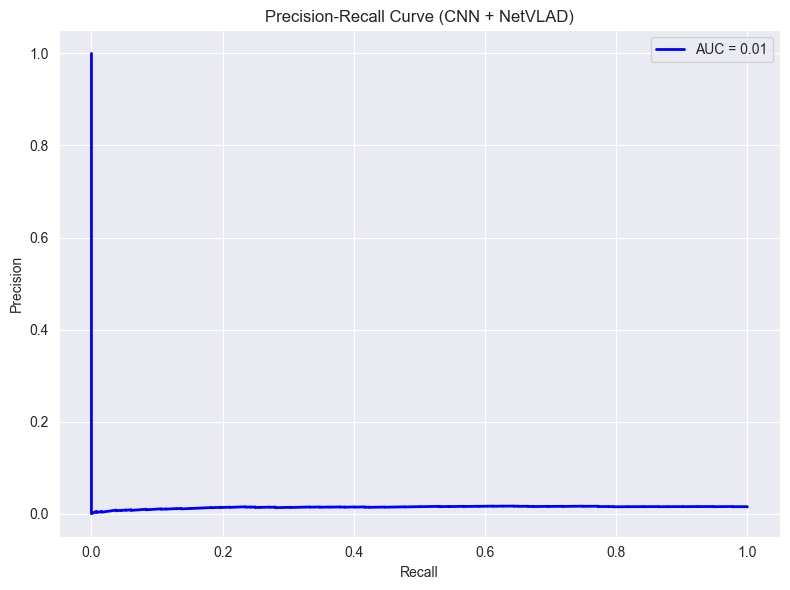

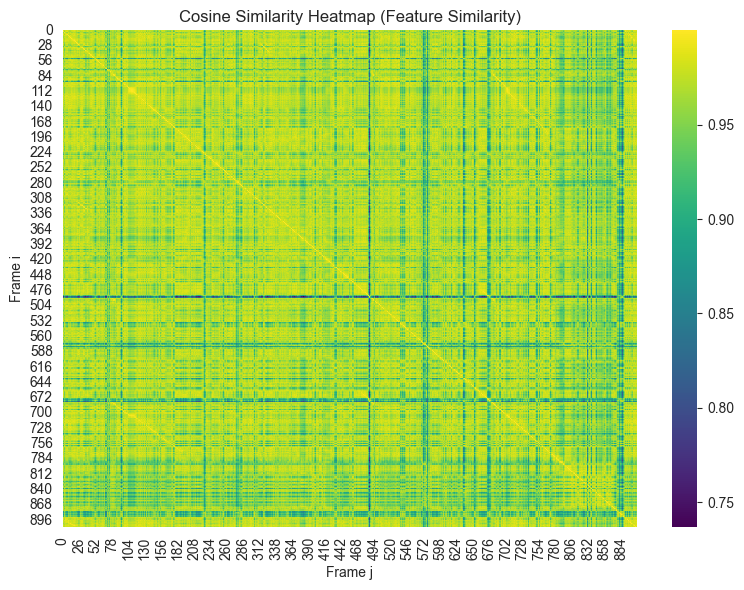

In [7]:
# ====================================================
# 7. VISUALIZATIONS
# ====================================================

# ---- PR Curve ----
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (CNN + NetVLAD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pr_curve_netvlad.png")
plt.show()

# ---- Similarity Heatmap ----
N = len(features)
sim_matrix = cosine_similarity(features, features)
plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, cmap='viridis')
plt.title('Cosine Similarity Heatmap (Feature Similarity)')
plt.xlabel('Frame j')
plt.ylabel('Frame i')
plt.tight_layout()
plt.savefig("similarity_heatmap.png")
plt.show()